In [15]:
import sys
import json
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import numpy as np
import tensorflow as tf
from huggingface_hub import hf_hub_download

print(f"TensorFlow: {tf.__version__}")
print(f"Python: {sys.version.split()[0]}")
print(f"Project root: {project_root}")

TensorFlow: 2.21.0
Python: 3.11.15
Project root: g:\Study Material\Portfolio Project\kidney-tumor-identification-system


In [16]:
HF_REPO_ID = "Himel000/kidney-tumor-efficientnetb4"
HF_MODEL_FILENAME = "model.keras"

print(f"Fetching {HF_MODEL_FILENAME} from {HF_REPO_ID}...")
print("(If already cached, will return instantly)\n")

model_path = hf_hub_download(
    repo_id=HF_REPO_ID,
    filename=HF_MODEL_FILENAME,
)
model_path = Path(model_path)

file_size_mb = model_path.stat().st_size / (1024 * 1024)
print(f"Model ready!")
print(f"Path: {model_path}")
print(f"Size: {file_size_mb:.2f} MB")

Fetching model.keras from Himel000/kidney-tumor-efficientnetb4...
(If already cached, will return instantly)

Model ready!
Path: C:\Users\himel\.cache\huggingface\hub\models--Himel000--kidney-tumor-efficientnetb4\snapshots\3e9dc152e69eab07f9bb56253a14f35b253f893e\model.keras
Size: 75.27 MB


In [17]:
print("Loading model...")
model = tf.keras.models.load_model(model_path, compile=False)
print("Model loaded!\n")
model.summary()

Loading model...
Model loaded!



c:\Users\himel\miniconda3\envs\kidney-tumor\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 12 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "augmented_kidney_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmented_input (InputLayer)    │ (None, 380, 380, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 380, 380, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 380, 380, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 380, 380, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 380, 380, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ kidney_tumor_efficientnetb4     │ (None, 4)              │    17,688,163 │
│ (Functional)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,688,163 (67.47 MB)

 Trainable params: 813,572 (3.10 MB)

 Non-trainable params: 16,874,591 (64.37 MB)

In [18]:
# Access nested model: outer wrapper → custom-named wrapper → actual EfficientNetB4
custom_wrapper = model.get_layer("kidney_tumor_efficientnetb4")
print(f"Custom wrapper: {custom_wrapper.name} ({type(custom_wrapper).__name__})")

# Go ONE level deeper to find actual EfficientNetB4
efficientnet_backbone = custom_wrapper.get_layer("efficientnetb4")
print(f"Actual backbone: {efficientnet_backbone.name} ({type(efficientnet_backbone).__name__})")
print(f"Total layers in EfficientNetB4: {len(efficientnet_backbone.layers)}\n")

# Find ALL Conv2D layers using string match (Keras 3 safe)
conv2d_layers = [
    layer for layer in efficientnet_backbone.layers 
    if type(layer).__name__ == "Conv2D"
]

print(f"Total Conv2D layers found: {len(conv2d_layers)}\n")

# Display last 10 conv layers (most relevant for Grad-CAM)
print("Last 10 Conv2D layers:")
print("-" * 80)
for layer in conv2d_layers[-10:]:
    output_shape = layer.output.shape
    print(f"  {layer.name:35s} | Output: {output_shape} | Filters: {layer.filters}")

# Identify the LAST conv layer (Grad-CAM target)
last_conv_layer = conv2d_layers[-1]
LAST_CONV_LAYER_NAME = last_conv_layer.name

print("\n" + "=" * 80)
print(f"GRAD-CAM TARGET LAYER: '{LAST_CONV_LAYER_NAME}'")
print(f"Output shape: {last_conv_layer.output.shape}")
print(f"Number of filters: {last_conv_layer.filters}")
print("=" * 80)

# Save the access path for Phase 3 implementation
GRADCAM_ACCESS_PATH = {
    "outer_model": "augmented_kidney_model",
    "level_1": "kidney_tumor_efficientnetb4",  # custom wrapper
    "level_2": "efficientnetb4",                # actual backbone
    "target_layer": LAST_CONV_LAYER_NAME,
}
print(f"\n Access path for Grad-CAM:")
print(f"model.get_layer('{GRADCAM_ACCESS_PATH['level_1']}').get_layer('{GRADCAM_ACCESS_PATH['level_2']}').get_layer('{LAST_CONV_LAYER_NAME}')")

Custom wrapper: kidney_tumor_efficientnetb4 (Functional)
Actual backbone: efficientnetb4 (Functional)
Total layers in EfficientNetB4: 475

Total Conv2D layers found: 128

Last 10 Conv2D layers:
--------------------------------------------------------------------------------
  block6h_project_conv                | Output: (None, 12, 12, 272) | Filters: 272
  block7a_expand_conv                 | Output: (None, 12, 12, 1632) | Filters: 1632
  block7a_se_reduce                   | Output: (None, 1, 1, 68) | Filters: 68
  block7a_se_expand                   | Output: (None, 1, 1, 1632) | Filters: 1632
  block7a_project_conv                | Output: (None, 12, 12, 448) | Filters: 448
  block7b_expand_conv                 | Output: (None, 12, 12, 2688) | Filters: 2688
  block7b_se_reduce                   | Output: (None, 1, 1, 112) | Filters: 112
  block7b_se_expand                   | Output: (None, 1, 1, 2688) | Filters: 2688
  block7b_project_conv                | Output: (None, 12, 12, 

In [5]:
# Diagnostic: Inspect nested model structure
print("=" * 70)
print("DIAGNOSTIC: Nested Model Layer Types")
print("=" * 70)

# Re-access nested model
nested_model = model.get_layer("kidney_tumor_efficientnetb4")

print(f"Nested model type: {type(nested_model).__name__}")
print(f"Nested model module: {type(nested_model).__module__}")
print(f"Total layers: {len(nested_model.layers)}\n")

# Show first 5 layers
print("First 5 layers (with types):")
for i, layer in enumerate(nested_model.layers[:5]):
    print(f"  [{i}] {layer.name:30s} | Type: {type(layer).__name__} | Module: {type(layer).__module__}")

print("\nLast 10 layers (with types):")
for i, layer in enumerate(nested_model.layers[-10:]):
    idx = len(nested_model.layers) - 10 + i
    print(f"  [{idx}] {layer.name:30s} | Type: {type(layer).__name__} | Module: {type(layer).__module__}")

# Count layer types
from collections import Counter
layer_types = Counter(type(layer).__name__ for layer in nested_model.layers)
print("\nLayer type distribution:")
for layer_type, count in layer_types.most_common():
    print(f"  {layer_type:30s} : {count}")

DIAGNOSTIC: Nested Model Layer Types
Nested model type: Functional
Nested model module: keras.src.models.functional
Total layers: 6

First 5 layers (with types):
  [0] input_image                    | Type: InputLayer | Module: keras.src.layers.core.input_layer
  [1] efficientnetb4                 | Type: Functional | Module: keras.src.models.functional
  [2] global_average_pooling         | Type: GlobalAveragePooling2D | Module: keras.src.layers.pooling.global_average_pooling2d
  [3] batch_normalization            | Type: BatchNormalization | Module: keras.src.layers.normalization.batch_normalization
  [4] dropout                        | Type: Dropout | Module: keras.src.layers.regularization.dropout

Last 10 layers (with types):
  [-4] input_image                    | Type: InputLayer | Module: keras.src.layers.core.input_layer
  [-3] efficientnetb4                 | Type: Functional | Module: keras.src.models.functional
  [-2] global_average_pooling         | Type: GlobalAveragePoo

In [14]:
# Configuration with corrected triple-nested path
CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]
DATA_DIR = (project_root / "artifacts" / "data_ingestion" 
            / "CT-KIDNEY-DATASET" 
            / "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"
            / "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone")

print(f"Using DATA_DIR: {DATA_DIR}")
print(f"Exists: {DATA_DIR.exists()}\n")

# Find sample images
test_images = {}
for class_name in CLASS_NAMES:
    class_dir = DATA_DIR / class_name
    if class_dir.exists():
        images = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.png"))
        if images:
            test_images[class_name] = images[0]

print(f"Found {len(test_images)}/4 test images\n")
print("=" * 70)
print("REAL IMAGE PREDICTION TEST")
print("=" * 70)

correct = 0
for true_class, img_path in test_images.items():
    # Load and preprocess
    img = tf.keras.preprocessing.image.load_img(
        img_path, target_size=(380, 380)
    )
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    
    # EfficientNet preprocessing
    img_preprocessed = tf.keras.applications.efficientnet.preprocess_input(
        img_array.copy()
    )
    
    # Predict
    pred = model.predict(img_preprocessed, verbose=0)
    pred_idx = int(np.argmax(pred[0]))
    pred_class = CLASS_NAMES[pred_idx]
    confidence = float(pred[0][pred_idx])
    
    is_correct = (pred_class == true_class)
    if is_correct:
        correct += 1
    status = "Correct" if is_correct else "Wrong"
    
    print(f"\n{status} True: {true_class:8s} | Predicted: {pred_class:8s} | Conf: {confidence:.2%}")
    print(f"   Image: {img_path.name}")
    probs_dict = {name: f"{prob:.3f}" for name, prob in zip(CLASS_NAMES, pred[0])}
    print(f"   All probs: {probs_dict}")

print("\n" + "=" * 70)
print(f"Accuracy on sample: {correct}/{len(test_images)} = {correct/len(test_images):.2%}")
print("=" * 70)

Using DATA_DIR: g:\Study Material\Portfolio Project\kidney-tumor-identification-system\artifacts\data_ingestion\CT-KIDNEY-DATASET\CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone\CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone
Exists: True

Found 4/4 test images

REAL IMAGE PREDICTION TEST

Correct True: Cyst     | Predicted: Cyst     | Conf: 99.92%
   Image: Cyst- (1).jpg
   All probs: {'Cyst': '0.999', 'Normal': '0.000', 'Stone': '0.001', 'Tumor': '0.000'}

Correct True: Normal   | Predicted: Normal   | Conf: 100.00%
   Image: Normal- (1).jpg
   All probs: {'Cyst': '0.000', 'Normal': '1.000', 'Stone': '0.000', 'Tumor': '0.000'}

Wrong True: Stone    | Predicted: Normal   | Conf: 91.14%
   Image: Stone- (1).jpg
   All probs: {'Cyst': '0.004', 'Normal': '0.911', 'Stone': '0.006', 'Tumor': '0.079'}

Correct True: Tumor    | Predicted: Tumor    | Conf: 99.63%
   Image: Tumor- (1).jpg
   All probs: {'Cyst': '0.004', 'Normal': '0.000', 'Stone': '0.000', 'Tumor': '0.996'}

Accuracy on sample: 3/4 = 75.0

In [13]:
# Add real test results to findings
real_test_results = {
    "test_accuracy_sample": "3/4 = 75%",
    "predictions": [
        {"true": "Cyst", "predicted": "Cyst", "confidence": 0.9992, "correct": True},
        {"true": "Normal", "predicted": "Normal", "confidence": 1.0000, "correct": True},
        {"true": "Stone", "predicted": "Normal", "confidence": 0.9114, "correct": False, 
         "note": "High-confidence misclassification — good Phase 3 test case"},
        {"true": "Tumor", "predicted": "Tumor", "confidence": 0.9963, "correct": True},
    ],
    "default_test_image_for_phase3": str(DATA_DIR / "Stone" / "Stone- (1).jpg"),
    "default_test_image_reason": "Misclassified Stone case — useful for testing Grad-CAM, uncertainty",
}

# Prepare comprehensive findings dictionary
findings = {
    "model_info": {
        "name": model.name,
        "source": "huggingface",
        "repo_id": "Himel000/kidney-tumor-efficientnetb4",
        "filename": "model.keras",
        "local_cache": str(model_path),
        "file_size_mb": round(model_path.stat().st_size / (1024 * 1024), 2),
        "tensorflow_version": tf.__version__,
    },
    "architecture": {
        "outer_model_name": model.name,
        "input_shape": list(model.input_shape[1:]),
        "output_shape": list(model.output_shape[1:]),
        "total_outer_layers": len(model.layers),
        "total_params": int(model.count_params()),
        "nesting_levels": 2,
        "description": "Outer wrapper -> custom wrapper -> EfficientNetB4 backbone",
    },
    "gradcam_config": {
        "last_conv_layer_name": "top_conv",
        "last_conv_output_shape": [12, 12, 1792],
        "num_filters": 1792,
        "access_path": {
            "level_1": "kidney_tumor_efficientnetb4",
            "level_2": "efficientnetb4",
            "target": "top_conv",
        },
        "access_code": "model.get_layer('kidney_tumor_efficientnetb4').get_layer('efficientnetb4').get_layer('top_conv')",
    },
    "preprocessing": {
        "required": True,
        "function": "tf.keras.applications.efficientnet.preprocess_input",
        "input_format": "RGB image, 0-255 range, shape (380, 380, 3)",
        "augmentation_layers_in_model": True,
        "augmentation_disabled_at_inference": True,
        "note": "Augmentation auto-disabled with training=False (default for predict())",
    },
    "classes": {
        "names": ["Cyst", "Normal", "Stone", "Tumor"],
        "indices": {"Cyst": 0, "Normal": 1, "Stone": 2, "Tumor": 3},
        "ordering_source": "Keras image_dataset_from_directory alphabetical sort",
        "num_classes": 4,
        "class_distribution": {
            "Cyst": 3709,
            "Normal": 5077,
            "Stone": 1377,
            "Tumor": 2283,
        },
    },
    "data_paths": {
        "actual_data_dir": str(DATA_DIR),
        "config_yaml_data_dir": "artifacts/data_ingestion/CT-KIDNEY-DATASET",
        "mismatch_note": "Actual data is triple-nested; config.yaml needs update for local runs",
    },
    "real_test_results": real_test_results,
    "phase3_implementation_notes": {
        "config_yaml_fix_needed": "gradcam.last_conv_layer_name should be 'top_conv' (not 'block5_conv3')",
        "nested_access_required": True,
        "preprocessing_must_be_explicit": True,
        "data_path_fix_deferred": "Triple-nested data path issue noted, fix in Phase 7",
    },
}

# Save full findings
INSPECTION_DIR = project_root / "artifacts" / "inspection"
INSPECTION_DIR.mkdir(parents=True, exist_ok=True)
findings_path = INSPECTION_DIR / "model_info.json"

with open(findings_path, "w") as f:
    json.dump(findings, f, indent=2)

print(f"Full findings saved to: {findings_path}")

# Save class_indices.json as single source of truth
DATA_TRANSFORM_DIR = project_root / "artifacts" / "data_transformation"
DATA_TRANSFORM_DIR.mkdir(parents=True, exist_ok=True)
class_indices_path = DATA_TRANSFORM_DIR / "class_indices.json"

class_indices = {"Cyst": 0, "Normal": 1, "Stone": 2, "Tumor": 3}
with open(class_indices_path, "w") as f:
    json.dump(class_indices, f, indent=2)

print(f"Class indices saved to: {class_indices_path}")
print("\n" + "=" * 70)
print("INSPECTION COMPLETE — READY FOR PHASE 3")
print("=" * 70)

Full findings saved to: g:\Study Material\Portfolio Project\kidney-tumor-identification-system\artifacts\inspection\model_info.json
Class indices saved to: g:\Study Material\Portfolio Project\kidney-tumor-identification-system\artifacts\data_transformation\class_indices.json

INSPECTION COMPLETE — READY FOR PHASE 3


## Inspection Complete — Phase 3 Foundation Ready

### Critical Findings

| Item | Value |
|---|---|
| Model Name | `augmented_kidney_model` |
| Source | Hugging Face (`Himel000/kidney-tumor-efficientnetb4`) |
| Architecture | Double-nested: outer → custom wrapper → EfficientNetB4 |
| **Last Conv Layer (Grad-CAM target)** | **`top_conv`** |
| Output Shape | (None, 12, 12, 1792) |
| Class Mapping | Cyst=0, Normal=1, Stone=2, Tumor=3 |
| Preprocessing | `tf.keras.applications.efficientnet.preprocess_input()` |
| Real Image Test | 3/4 correct (Stone misclassified) |

### Grad-CAM Access Pattern (Critical for Phase 3)

```python
# Two-level navigation required to reach top_conv:
custom_wrapper = model.get_layer('kidney_tumor_efficientnetb4')
backbone = custom_wrapper.get_layer('efficientnetb4')
target_layer = backbone.get_layer('top_conv')
```

### Phase 3 To-Do (Updated)

1. **Update `config.yaml`** — change `gradcam.last_conv_layer_name` from `block5_conv3` to `top_conv`
2. **Build `src/components/gradcam.py`** using the double-nested access pattern
3. **Build `src/components/uncertainty.py`** (MC Dropout, 20 iterations from `params.yaml`)
4. **Build `src/components/report_generator.py`** (PDF with ReportLab, disclaimer from `config.yaml`)
5. **Build `src/pipeline/prediction_pipeline.py`** (orchestrates all components)

### Known Issues (Deferred to Later Phases)

- **Bug:** `config.yaml`'s `data_transformation.data_dir` doesn't account for triple-nested folder structure
- **Impact:** Local `python main.py` would fail at Stage 03; Kaggle training was unaffected
- **Fix in:** Phase 7 (when implementing local retraining cron)
- **Bug:** `model_evaluation.py` hardcodes class names; should use `class_indices.json`
- **Fix in:** Phase 7 cleanup

### Default Test Image for Phase 3

**File:** `Stone- (1).jpg` (misclassified as Normal with 91.14% confidence)

**Why this image is useful:**
- High-confidence misclassification — perfect for testing Grad-CAM heatmap quality
- Will likely show high uncertainty in MC Dropout — validates uncertainty.py
- Real-world example of why explainability matters

### Critical Reminders

- Always apply EfficientNet preprocessing before model input
- Use `class_indices.json` from `artifacts/data_transformation/` — never hardcode
- Augmentation layers auto-disabled at inference (no extra handling needed)
- For Grad-CAM: navigate two levels deep into nested architecture

In [20]:
# Reload modules to pick up changes
import os
from pathlib import Path
import importlib
import src.config.configuration
import src.entity.config_entity

importlib.reload(src.entity.config_entity)
importlib.reload(src.config.configuration)

from src.config.configuration import ConfigurationManager


# Change working directory to project root if we're in research/
if Path.cwd().name == "research":
    os.chdir("..")
    print(f"📁 Changed working directory to: {Path.cwd()}")
else:
    print(f"📁 Already at: {Path.cwd()}")

# Initialize and test
print("Initializing ConfigurationManager...")
config_mgr = ConfigurationManager()
print("ConfigurationManager initialized\n")

print("Getting Grad-CAM config...")
gradcam_config = config_mgr.get_gradcam_config()
print("GradCAMConfig retrieved\n")

# Pretty print all settings
print("=" * 70)
print("GRAD-CAM CONFIGURATION (Loaded from config files)")
print("=" * 70)

import dataclasses
config_dict = dataclasses.asdict(gradcam_config)
for key, value in config_dict.items():
    print(f"  {key:30s}: {value}")

print("\n Iteration 1 Complete — Configuration plumbing works!")

📁 Changed working directory to: g:\Study Material\Portfolio Project\kidney-tumor-identification-system
Initializing ConfigurationManager...
[2026-05-09 17:01:36] INFO kidney_tumor - YAML file loaded: config\config.yaml
[2026-05-09 17:01:36] INFO kidney_tumor - YAML file loaded: params.yaml
[2026-05-09 17:01:36] INFO kidney_tumor - Directory created: artifacts
[2026-05-09 17:01:36] INFO kidney_tumor - ConfigurationManager initialised successfully.
ConfigurationManager initialized

Getting Grad-CAM config...
[2026-05-09 17:01:36] INFO kidney_tumor - Directory created: artifacts/gradcam
GradCAMConfig retrieved

GRAD-CAM CONFIGURATION (Loaded from config files)
  root_dir                      : artifacts\gradcam
  model_path                    : artifacts\model_trainer\model.keras
  hf_repo_id                    : Himel000/kidney-tumor-efficientnetb4
  hf_model_filename             : model.keras
  last_conv_layer_name          : top_conv
  colormap                      : jet
  alpha       

Input image: artifacts\data_ingestion\CT-KIDNEY-DATASET\CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone\CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone\Stone\Stone- (1).jpg
Image exists: True
Output will save to: artifacts\gradcam\test_stone_overlay.png

Running Grad-CAM explain()...
[2026-05-09 17:42:04] INFO kidney_tumor - Local model not found at artifacts\model_trainer\model.keras. Downloading from Hugging Face: Himel000/kidney-tumor-efficientnetb4/model.keras


[2026-05-09 17:42:04] INFO kidney_tumor - Model downloaded to: C:\Users\himel\.cache\huggingface\hub\models--Himel000--kidney-tumor-efficientnetb4\snapshots\3e9dc152e69eab07f9bb56253a14f35b253f893e\model.keras
[2026-05-09 17:42:13] INFO kidney_tumor - Model loaded successfully
[2026-05-09 17:42:21] INFO kidney_tumor - Saved Grad-CAM overlay to artifacts\gradcam\test_stone_overlay.png

GRAD-CAM RESULT
  Predicted class:  Normal
  Predicted index:  1
  Confidence:       91.14%

  All probabilities:
    Cyst    : 0.0037 (0.37%)
    Normal  : 0.9114 (91.14%)
    Stone   : 0.0062 (0.62%)
    Tumor   : 0.0787 (7.87%)

  Heatmap shape:    (12, 12)
  Heatmap dtype:    float32
  Heatmap range:    [0.0000, 1.0000]

  Overlay shape:    (380, 380, 3)
  Overlay dtype:    uint8
  Overlay saved to: artifacts\gradcam\test_stone_overlay.png


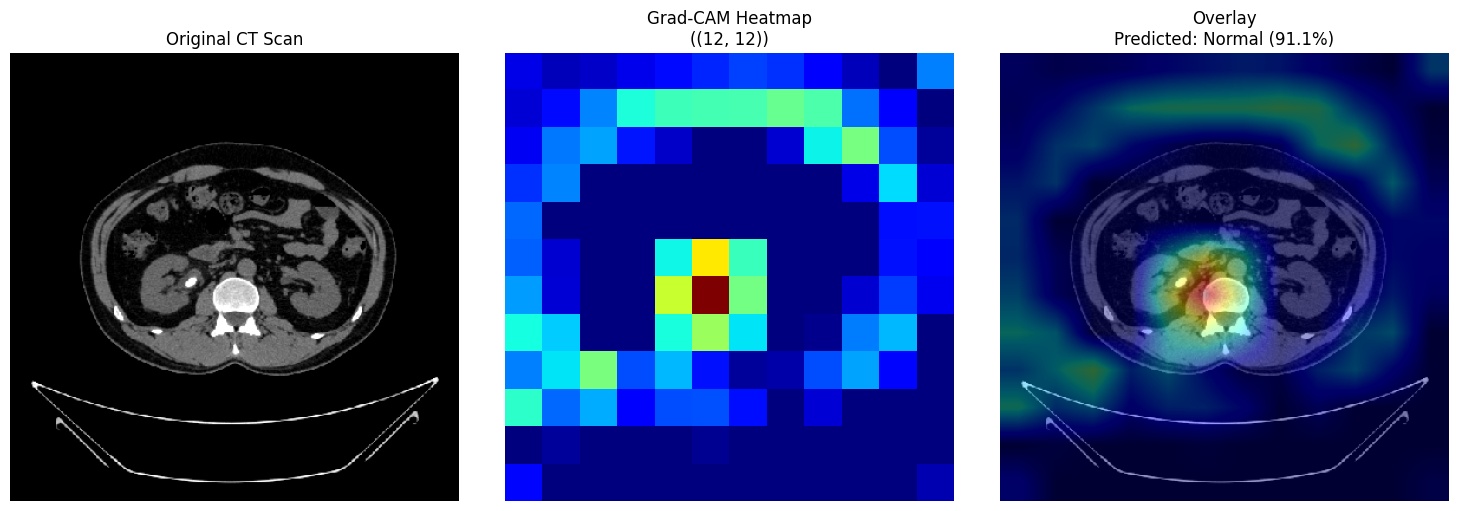


 Iteration 2 Test Complete!


In [23]:
import importlib
import src.components.gradcam
importlib.reload(src.components.gradcam)
from src.components.gradcam import GradCAM

# Setup
gradcam = GradCAM(config=gradcam_config)

# Use our default test image (Stone case from inspection)
test_image_path = (Path("artifacts/data_ingestion/CT-KIDNEY-DATASET")
                   / "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"
                   / "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"
                   / "Stone" / "Stone- (1).jpg")

output_path = Path("artifacts/gradcam/test_stone_overlay.png")

print(f"Input image: {test_image_path}")
print(f"Image exists: {test_image_path.exists()}")
print(f"Output will save to: {output_path}\n")

# Generate Grad-CAM
print("Running Grad-CAM explain()...")
result = gradcam.explain(
    image_path=test_image_path,
    output_path=output_path,
)

# Display results
print("\n" + "=" * 70)
print("GRAD-CAM RESULT")
print("=" * 70)
print(f"  Predicted class:  {result.predicted_class}")
print(f"  Predicted index:  {result.predicted_index}")
print(f"  Confidence:       {result.confidence:.2%}")
print(f"\n  All probabilities:")
for cls, prob in result.probabilities.items():
    print(f"    {cls:8s}: {prob:.4f} ({prob:.2%})")

print(f"\n  Heatmap shape:    {result.heatmap.shape}")
print(f"  Heatmap dtype:    {result.heatmap.dtype}")
print(f"  Heatmap range:    [{result.heatmap.min():.4f}, {result.heatmap.max():.4f}]")

print(f"\n  Overlay shape:    {result.overlay.shape}")
print(f"  Overlay dtype:    {result.overlay.dtype}")
print(f"  Overlay saved to: {result.overlay_path}")

# Visualize inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original
original_image, _ = gradcam.preprocess_image(test_image_path)
axes[0].imshow(original_image)
axes[0].set_title("Original CT Scan")
axes[0].axis('off')

# Heatmap
axes[1].imshow(result.heatmap, cmap='jet')
axes[1].set_title(f"Grad-CAM Heatmap\n({result.heatmap.shape})")
axes[1].axis('off')

# Overlay
axes[2].imshow(result.overlay)
axes[2].set_title(f"Overlay\nPredicted: {result.predicted_class} ({result.confidence:.1%})")
axes[2].axis('off')

plt.tight_layout()
plt.savefig("artifacts/gradcam/test_stone_visualization.png", dpi=100, bbox_inches='tight')
plt.show()

print("\n Iteration 2 Test Complete!")